# ISLP - Chapter 8 - Exercise 8
### Author: pzuehlke

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
import seaborn as sns

We begin by loading the dataset:

In [5]:
carseats = pd.read_csv("Carseats.csv")
carseats = carseats.dropna()
carseats.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [7]:
n, p = carseats.shape
print(n, p)
carseats.info()

400 11
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        400 non-null    float64
 1   CompPrice    400 non-null    int64  
 2   Income       400 non-null    int64  
 3   Advertising  400 non-null    int64  
 4   Population   400 non-null    int64  
 5   Price        400 non-null    int64  
 6   ShelveLoc    400 non-null    object 
 7   Age          400 non-null    int64  
 8   Education    400 non-null    int64  
 9   Urban        400 non-null    object 
 10  US           400 non-null    object 
dtypes: float64(1), int64(7), object(3)
memory usage: 34.5+ KB


__8 (a):__ To fit a regression tree in item (b) using sklearn, we will need to
one-hot encode the `ShelveLoc` variable. Then we split the data into train and
test sets.

In [12]:
carseats = pd.get_dummies(carseats, drop_first=True)

In [13]:
X = carseats.drop(columns=["Sales"], axis=1)
y = carseats["Sales"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

__8 (b):__ For the single regression tree below we obtain a test MSE of $ 5.43 $. The most important features
in predicting sales seem to be: `Price`, a good `ShelveLoc`, `Age` and `CompPrice`.

In [14]:
reg_tree = DecisionTreeRegressor(random_state=0)
reg_tree.fit(X_train, y_train)

DecisionTreeRegressor(random_state=0)

In [ ]:
y_pred = reg_tree.predict(X_test)
test_mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE for the full tree: {test_mse:.4f}")
print(f"The tree's depth is {reg_tree.get_depth()}")

Test MSE for the full tree: 5.4279
The tree's depth is 14


In [26]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": reg_tree.feature_importances_
}).sort_values("Importance", ascending=False)

print(feature_importance.head(10))

             Feature  Importance
4              Price    0.279673
7     ShelveLoc_Good    0.218034
5                Age    0.118255
0          CompPrice    0.110876
8   ShelveLoc_Medium    0.087200
2        Advertising    0.061020
3         Population    0.045051
1             Income    0.040933
6          Education    0.029877
10            US_Yes    0.006229


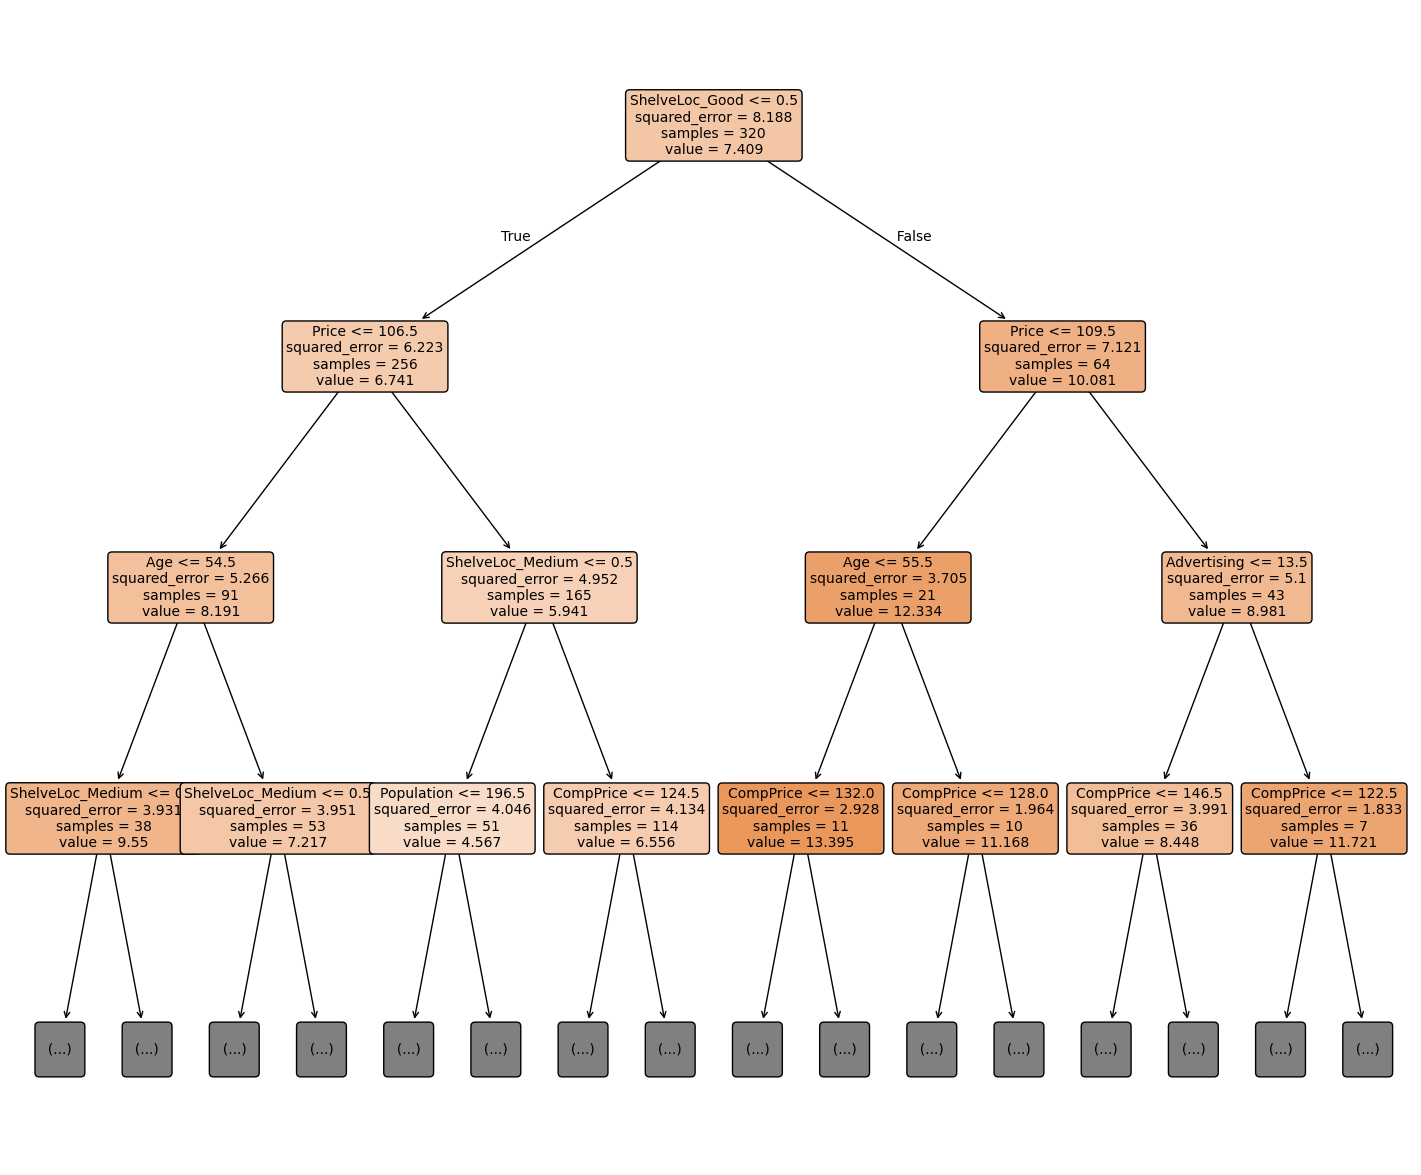

In [23]:
plt.figure(figsize=(18, 15))
plot_tree(reg_tree, max_depth=3, feature_names=X.columns, filled=True, rounded=True, fontsize=10)
plt.show()

__8 (c):__

In [48]:
unpruned_mse = test_mse
path = reg_tree.cost_complexity_pruning_path(X_train, y_train)

# Cross-validation to find optimal complexity:
param_grid = {"ccp_alpha": path.ccp_alphas}
grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=0),
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=0),
             param_grid={'ccp_alpha': array([0.00000000e+00, 8.88178420e-17, 1.56250000e-07, 1.56250000e-07,
       1.56250000e-07, 1.56250000e-07, 1.56250000e-07, 1.56250000e-07,
       2.08333333e-07, 1.40625000e-06, 1.40625000e-06, 1.40625000e-06,
       1.40625000e-06, 1.40625000e-06, 2.50000000e-06, 2.50000000e-06,
       2.50000000e-0...
       7.04003384e-02, 7.63041038e-02, 8.11496299e-02, 9.27628907e-02,
       9.28200335e-02, 1.00129280e-01, 1.04223039e-01, 1.14031253e-01,
       1.15451446e-01, 1.22270189e-01, 1.42280557e-01, 1.49223343e-01,
       1.64246541e-01, 1.96233479e-01, 2.08429809e-01, 2.19330466e-01,
       3.76423622e-01, 4.35706050e-01, 4.95811947e-01, 9.27714395e-01,
       1.78523002e+00])},
             scoring='neg_mean_squared_error')

In [ ]:
# Get best alpha and fit optimal tree:
best_alpha = grid_search.best_params_["ccp_alpha"]
optimal_tree = DecisionTreeRegressor(ccp_alpha=best_alpha, random_state=0)
optimal_tree.fit(X_train, y_train)

In [ ]:
optimal_pred = optimal_tree.predict(X_test)
optimal_mse = mean_squared_error(y_test, optimal_pred)

print(f"Optimal MSE: {round(optimal_mse, 4)}")
print(f"Unpruned MSE: {round(unpruned_mse, 4)}")

Optimal MSE: 5.1943
Unpruned MSE: 5.4279
0.04303690193260746


We conclude that cost-complexity pruning was able to slightly reduce the test MSE from $ 5.43 $ to $ 5.19 $, a relative difference of $ 4.4 \% $.


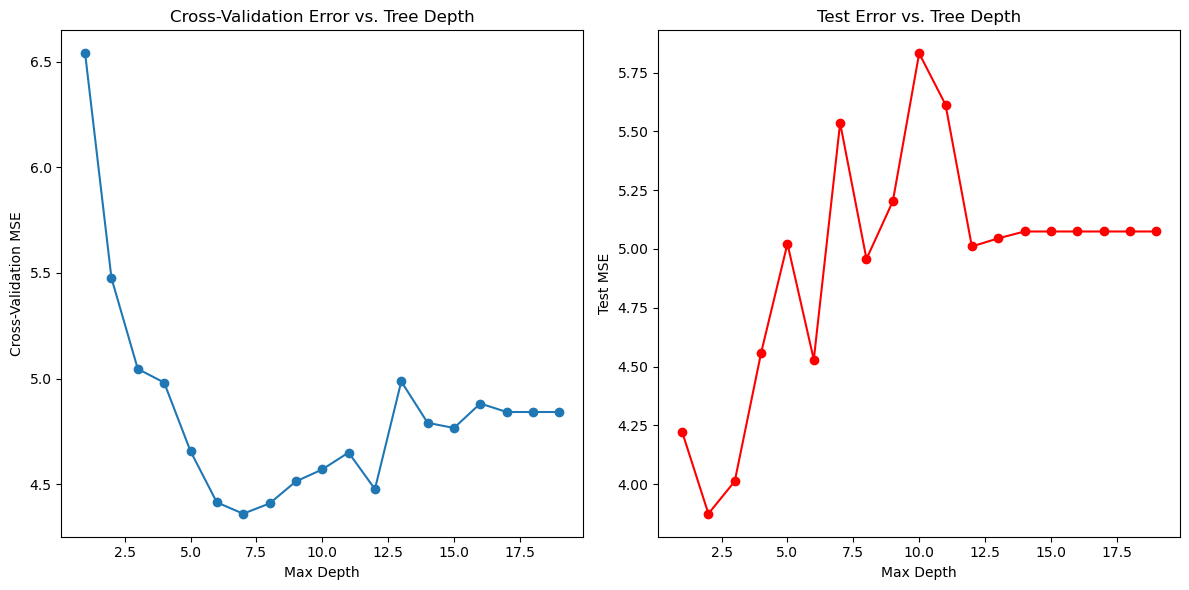

In [31]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(max_depths, cv_scores, marker="o", linestyle="-")
plt.xlabel("Max Depth")
plt.ylabel("Cross-Validation MSE")
plt.title("Cross-Validation Error vs. Tree Depth")

plt.subplot(1, 2, 2)
plt.plot(max_depths, test_scores, marker="o", linestyle="-", color="r")
plt.xlabel("Max Depth")
plt.ylabel("Test MSE")
plt.title("Test Error vs. Tree Depth")
plt.tight_layout()
plt.show()

In [ ]:

# Get the best parameters
best_params = grid_search.best_params_
print(f"\nOptimal tree parameters: {best_params}")

# Fit the pruned tree with optimal parameters
pruned_tree = DecisionTreeRegressor(
    max_depth=best_params["max_depth"],
    min_samples_split=best_params["min_samples_split"],
    min_samples_leaf=best_params["min_samples_leaf"],
    random_state=123
)
pruned_tree.fit(X_train, y_train)

# Plot the pruned tree
plt.figure(figsize=(20, 10))
plot_tree(pruned_tree, max_depth=3, feature_names=X.columns, filled=True, rounded=True, fontsize=10)
plt.savefig("pruned_regression_tree.png", bbox_inches="tight")
plt.close()

# Make predictions with the pruned tree
y_pruned_pred = pruned_tree.predict(X_test)

# Calculate test MSE with the pruned tree
pruned_test_mse = mean_squared_error(y_test, y_pruned_pred)
print(f"\nTest MSE for the pruned tree: {pruned_test_mse:.4f}")

# Compare MSE improvement
mse_improvement = ((test_mse - pruned_test_mse) / test_mse) * 100
print(f"MSE improvement from pruning: {mse_improvement:.2f}%")

# Visualize the cross-validation results
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results["mean_mse"] = -cv_results["mean_test_score"]

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=cv_results.groupby("param_max_depth")["mean_mse"].mean().reset_index(),
    x="param_max_depth",
    y="mean_mse"
)
plt.xlabel("Maximum Tree Depth")
plt.ylabel("Mean Cross-Validation MSE")
plt.title("Cross-Validation MSE vs. Tree Depth")
plt.savefig("cv_results.png")
plt.close()

# Visualize actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pruned_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Pruned Tree)")
plt.savefig("actual_vs_predicted.png")
plt.close()

# Summary of results
print("\nSummary of Results:")
print(f"1. Full tree test MSE: {test_mse:.4f}")
print(f"2. Pruned tree test MSE: {pruned_test_mse:.4f}")
print(f"3. Optimal max_depth: {best_params['max_depth']}")
print(f"4. Does pruning improve test MSE? {'Yes' if pruned_test_mse < test_mse else 'No'}")